<a href="https://colab.research.google.com/github/97AkshatParab/KISAN-AI-/blob/main/crop_disease_detection_YOLOv8distillated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          import tensorflow_datasets as tfds

# Load PlantVillage dataset
dataset, info = tfds.load('plant_village', with_info=True)
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.TGC9UE_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='plant_village',
    full_name='plant_village/1.0.2',
    description="""
    The PlantVillage dataset consists of 54303 healthy and unhealthy leaf images
    divided into 38 categories by species and disease.
    
    NOTE: The original dataset is not available from the original source
    (plantvillage.org), therefore we get the unaugmented dataset from a paper that
    used that dataset and republished it. Moreover, we dropped images with
    Background_without_leaves label, because these were not present in the original
    dataset.
    
    Original paper URL: https://arxiv.org/abs/1511.08060 Dataset URL:
    https://data.mendeley.com/datasets/tywbtsjrjv/1
    """,
    homepage='https://arxiv.org/abs/1511.08060',
    data_dir='/root/tensorflow_datasets/plant_village/1.0.2',
    file_format=tfrecord,
    download_size

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
import os

# Path to your Google Drive folder
save_dir = "/content/drive/MyDrive/BE Major Project/Plant Village"
os.makedirs(save_dir, exist_ok=True)

# Load PlantVillage dataset
dataset, info = tfds.load("plant_village", with_info=True, as_supervised=True)

# Loop through splits (train/test) and save images
for split, ds in dataset.items():
    split_dir = os.path.join(save_dir, split)
    os.makedirs(split_dir, exist_ok=True)

    print(f"Saving {split} images to {split_dir} ...")
    count = 0
    for img, label in tfds.as_numpy(ds):
        # Get class name
        class_name = info.features['label'].int2str(label)
        class_dir = os.path.join(split_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        # Save image as PNG
        img_path = os.path.join(class_dir, f"{count}.png")
        tf.keras.utils.save_img(img_path, img)
        count += 1

    print(f" Done saving {count} images for {split}.")


Saving train images to /content/drive/MyDrive/BE Major Project/Plant Village/train ...
✅ Done saving 54303 images for train.


In [ ]:
import os, shutil, random
from sklearn.model_selection import train_test_split

base_dir = "/content/drive/MyDrive/BE Major Project/Plant Village/train"
train_dir = "/content/drive/MyDrive/BE Major Project/Plant Village/custom_train"
test_dir = "/content/drive/MyDrive/BE Major Project/Plant Village/custom_test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class subfolders
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Copy images
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))

print("✅ Train/Test split completed!")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BE Major Project/Plant Village/train'

In [ ]:
!pip install torch


In [ ]:
import os
import yaml

# Path to dataset
dataset_path = "/content/drive/MyDrive/BE Major Project/Plant Village"

# Create yaml dictionary
data_yaml = {
    'path': dataset_path,   # Root dataset path
    'train': 'train',       # Train folder
    'val': 'test',          # Validation folder
    'names': sorted([d for d in os.listdir(f"{dataset_path}/train") if not d.startswith('.')])  # Class names from train dir
}

# Save yaml file
yaml_path = "/content/drive/MyDrive/BE Major Project/plantvillage_cls.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✅ YAML file created at: {yaml_path}")
print("Classes:", data_yaml['names'])


✅ YAML file created at: /content/drive/MyDrive/BE Major Project/plantvillage_cls.yaml
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spide

In [ ]:
from ultralytics import YOLO

# Load a YOLOv8 model
model = YOLO("yolov8l-cls.pt")

# Verify dataset
model.train(data="/content/drive/MyDrive/BE Major Project/Plant Village/custom_train", epochs=1, imgsz=224)


Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BE Major Project/Plant Village/custom_train, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b63200a7830>
curves: []
curves_results: []
fitness: 0.9945559799671173
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9891119599342346, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9945559799671173}
save_dir: PosixPath('/content/runs/classify/train8')
speed: {'preprocess': 0.11334718033225334, 'inference': 1.6022200990126196, 'loss': 0.0008035971412178735, 'postprocess': 0.001085154813598148}
task: 'classify'
top1: 0.9891119599342346
top5: 1.0

In [ ]:
import os
import yaml

# Paths to your dataset
BASE = "/content/drive/MyDrive/BE Major Project/Plant Village"
TRAIN_FOLDER = "custom_train"
VAL_FOLDER = "custom_test"

# Get classes from train folder
train_path = os.path.join(BASE, TRAIN_FOLDER)
classes = [d for d in sorted(os.listdir(train_path)) if os.path.isdir(os.path.join(train_path, d))]

# YAML structure for YOLOv8
data_yaml = {
    'path': BASE,              # root dataset folder
    'train': TRAIN_FOLDER,     # train folder
    'val': VAL_FOLDER,         # validation/test folder
    'nc': len(classes),        # number of classes
    'names': classes           # class names
}

# Save YAML file
yaml_path = os.path.join(BASE, "plantvillage.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"YAML file created at: {yaml_path}")
print("Classes detected:", classes)


YAML file created at: /content/drive/MyDrive/BE Major Project/Plant Village/plantvillage.yaml
Classes detected: ['Apple___Cedar_apple_rust', 'Apple___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Tomato___Late_blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot']


In [ ]:
print("Train classes:", os.listdir(os.path.join(BASE, TRAIN_FOLDER)))
print("Test classes:", os.listdir(os.path.join(BASE, VAL_FOLDER)))

Train classes: ['Tomato___Target_Spot', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Late_blight', 'Potato___Early_blight', 'Apple___healthy', 'Apple___Cedar_apple_rust', 'Pepper,_bell___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Bacterial_spot', 'Squash___Powdery_mildew']
Test classes: ['Tomato___Target_Spot', 'Orange___Haunglongbing_(Citrus_greening)', 'Tomato___Late_blight', 'Potato___Early_blight', 'Apple___healthy', 'Apple___Cedar_apple_rust', 'Pepper,_bell___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Bacterial_spot', 'Squash___Powdery_mildew']


In [ ]:
!pip install albumentations

In [ ]:
!pip install albumentations opencv-python-headless

In [ ]:
import os
import cv2
from albumentations import (
    Compose, HorizontalFlip, VerticalFlip, Rotate,
    RandomBrightnessContrast, ShiftScaleRotate
)

# Define augmentation transforms
transform = Compose([
    HorizontalFlip(p=0.5),
    VerticalFlip(p=0.5),
    Rotate(limit=30, p=0.5),
    RandomBrightnessContrast(p=0.5),
    ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5)
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# Paths
BASE = "/content/drive/MyDrive/BE Major Project/Plant Village"
TRAIN_FOLDER = "custom_train"
AUG_FOLDER = "custom_train_aug"  # new folder to save augmented images

# Create augmented dataset folder
os.makedirs(os.path.join(BASE, AUG_FOLDER), exist_ok=True)

# Loop through each class folder
for class_name in os.listdir(os.path.join(BASE, TRAIN_FOLDER)):
    class_input_path = os.path.join(BASE, TRAIN_FOLDER, class_name)
    class_output_path = os.path.join(BASE, AUG_FOLDER, class_name)
    os.makedirs(class_output_path, exist_ok=True)

    for img_file in os.listdir(class_input_path):
        img_path = os.path.join(class_input_path, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Save original image in augmented folder as well
        cv2.imwrite(os.path.join(class_output_path, img_file), img)

        # Apply augmentation N times (e.g., 2 extra images per original)
        for i in range(2):
            augmented = transform(image=img)['image']
            aug_filename = img_file.split('.')[0] + f"_aug{i}.png"
            cv2.imwrite(os.path.join(class_output_path, aug_filename), augmented)

print("Data augmentation completed! Augmented dataset saved in:", os.path.join(BASE, AUG_FOLDER))


Data augmentation completed! Augmented dataset saved in: /content/drive/MyDrive/BE Major Project/Plant Village/custom_train_aug


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
# Colab cell: Heuristic segmentation for PlantVillage (fast)
# Run after mounting Drive

import os, glob
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

BASE = "/content/drive/MyDrive/BE Major Project/Plant Village"
SPLITS = ["custom_train", "custom_test"]
MASK_ROOT = os.path.join(BASE, "masks_heuristic")  # output masks are saved here
os.makedirs(MASK_ROOT, exist_ok=True)

# HSV thresholds - tweak if needed
# These are tuned for green leaves on lighter backgrounds; adjust for other crops/colors
LOWER_HSV = np.array([20, 30, 30])   # H,S,V
UPPER_HSV = np.array([95, 255, 255])

# Min area (pixels) to keep contour as leaf
MIN_LEAF_AREA = 500

def make_mask_from_image(img_bgr):
    h, w = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LOWER_HSV, UPPER_HSV)

    # Invert if background darker vs leaf brightness — optional heuristic
    # If mean intensity is high (white background), contours already ok.
    # Morphological closing/opening to clean mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Keep largest contours and fill them
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_filled = np.zeros_like(mask)
    for c in contours:
        area = cv2.contourArea(c)
        if area < MIN_LEAF_AREA:
            continue
        cv2.drawContours(mask_filled, [c], -1, 255, thickness=cv2.FILLED)
    # fallback: if mask_filled is empty, return original threshold mask (helps with varying colors)
    if mask_filled.sum() == 0:
        mask_filled = mask
    return mask_filled

# Process dataset
for split in SPLITS:
    split_dir = os.path.join(BASE, split)
    if not os.path.exists(split_dir):
        print(f"Skip, not found: {split_dir}")
        continue
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        out_cls_dir = os.path.join(MASK_ROOT, split, cls)
        os.makedirs(out_cls_dir, exist_ok=True)
        img_paths = sorted(glob.glob(os.path.join(cls_dir, "*.*")))
        for img_path in tqdm(img_paths, desc=f"{split}/{cls}", unit="img"):
            if not img_path.lower().endswith(('.jpg','.jpeg','.png')):
                continue
            out_mask = os.path.join(out_cls_dir, Path(img_path).stem + ".png")
            if os.path.exists(out_mask):
                continue  # skip if already created
            img = cv2.imread(img_path)
            if img is None:
                continue
            mask = make_mask_from_image(img)
            # Save mask as binary PNG (0 or 255)
            cv2.imwrite(out_mask, mask)

print("Heuristic mask generation done. Masks are in:", MASK_ROOT)

custom_train/Apple___healthy: 100%|██████████| 1316/1316 [01:08<00:00, 19.11img/s]
custom_train/Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 4405/4405 [03:39<00:00, 20.05img/s]
custom_train/Tomato___Late_blight: 100%|██████████| 1526/1526 [01:08<00:00, 22.30img/s]
custom_train/Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1340/1340 [00:54<00:00, 24.48img/s]
custom_test/Apple___healthy: 100%|██████████| 329/329 [00:15<00:00, 21.51img/s]
custom_test/Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 1102/1102 [01:41<00:00, 10.84img/s]
custom_test/Potato___Early_blight: 100%|██████████| 200/200 [00:09<00:00, 21.73img/s]
custom_test/Squash___Powdery_mildew: 0img [00:00, ?img/s]
custom_test/Tomato___Late_blight: 100%|██████████| 382/382 [00:19<00:00, 19.16img/s]
custom_test/Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 336/336 [00:19<00:00, 17.38img/s]
custom_test/Tomato___Target_Spot: 100%|██████████| 281/281 [00:16<00:00, 16.79img/

Heuristic mask generation done. Masks are in: /content/drive/MyDrive/BE Major Project/Plant Village/masks_heuristic


In [ ]:
import cv2
import numpy as np
import os
from glob import glob

# ===============================
# CONFIG
# ===============================
dataset_path = "/content/drive/MyDrive/BE Major Project/Plant Village/custom_train"
mask_output_path = "/content/drive/MyDrive/BE Major Project/Plant Village/segmented_masks"
label_output_path = "/content/drive/MyDrive/BE Major Project/Plant Village/labels"

os.makedirs(mask_output_path, exist_ok=True)
os.makedirs(label_output_path, exist_ok=True)

# ===============================
# STEP 1: Helper Functions
# ===============================
def segment_leaf(image):
    """Extracts leaf from background using HSV thresholding + contour mask."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # green range for leaves
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Morphological cleaning
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

def segment_disease(image, leaf_mask):
    """Detects diseased spots within the leaf area."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # yellow/brown range for disease
    lower_brown = np.array([10, 50, 50])
    upper_brown = np.array([35, 255, 255])

    disease_mask = cv2.inRange(hsv, lower_brown, upper_brown)

    # keep only inside leaf
    disease_mask = cv2.bitwise_and(disease_mask, leaf_mask)

    return disease_mask

def mask_to_yolo_bboxes(mask, img_w, img_h, class_id=0):
    """Converts binary mask → YOLO bounding boxes (normalized)."""
    bboxes = []
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w*h > 100:  # filter out noise
            # YOLO format (class, x_center, y_center, w, h) normalized
            x_center = (x + w/2) / img_w
            y_center = (y + h/2) / img_h
            w_norm = w / img_w
            h_norm = h / img_h
            bboxes.append([class_id, x_center, y_center, w_norm, h_norm])
    return bboxes

# ===============================
# STEP 2: Process Dataset
# ===============================
image_files = glob(os.path.join(dataset_path, "*.jpg")) + glob(os.path.join(dataset_path, "*.png"))

for img_path in image_files:
    image = cv2.imread(img_path)
    if image is None:
        continue

    h, w, _ = image.shape
    filename = os.path.splitext(os.path.basename(img_path))[0]

    # Leaf segmentation
    leaf_mask = segment_leaf(image)

    # Disease segmentation
    disease_mask = segment_disease(image, leaf_mask)

    # Combine leaf + disease mask for saving
    combined_mask = np.zeros_like(leaf_mask)
    combined_mask[leaf_mask > 0] = 128   # leaf = gray
    combined_mask[disease_mask > 0] = 255  # disease = white

    # Save segmentation mask
    cv2.imwrite(f"{mask_output_path}/{filename}_mask.png", combined_mask)

    # Convert mask → bounding boxes
    bboxes = mask_to_yolo_bboxes(disease_mask, w, h, class_id=0)

    # Save YOLO labels
    with open(f"{label_output_path}/{filename}.txt", "w") as f:
        for box in bboxes:
            f.write(" ".join(map(str, box)) + "\n")

print("✅ Segmentation masks + YOLO bounding boxes generated successfully!")


✅ Segmentation masks + YOLO bounding boxes generated successfully!


In [ ]:
!pip install -q ultralytics==8.3.204

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.4 MB/s eta 0:00:00


In [ ]:
!pip install -q roboflow tqdm matplotlib pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 92.4 MB/s eta 0:00:00


In [ ]:
!pip install -q ultralytics==8.3.204 tqdm pillow seaborn pandas

In [ ]:
!ls /content/drive/MyDrive/BE\ Major\ Project/Plant\ Village

 1511.08060v2.pdf   custom_train_aug    runs		 'Zip file_raw'
 custom_test	    masks_heuristic     segmented_masks
 custom_train	    plantvillage.yaml   train


In [ ]:
# Colab: Cell A1
import os
BASE = "/content/drive/MyDrive/BE Major Project/Plant Village"
TRAIN_AUG = os.path.join(BASE, "custom_train_aug")   # use augmented training
TRAIN_ORIG = os.path.join(BASE, "custom_train")     # original
VAL_FOLDER = os.path.join(BASE, "custom_test")

# Combine both training folders into a single pool for teacher/student if you want:
USE_COMBINED_TRAIN = True

# Run dirs
RUNS = os.path.join(BASE, "runs")
PSEUDO_ROOT = os.path.join(BASE, "PlantVillage_pseudo")   # pseudo images + labels
STUDENT_ROOT = os.path.join(BASE, "PlantVillage_student") # student images/labels layout
UNLABELED_POOL = os.path.join(BASE, "PV_unlabeled_pool")  # images teacher will label (we'll collect from train/val)

os.makedirs(RUNS, exist_ok=True)
os.makedirs(PSEUDO_ROOT, exist_ok=True)
os.makedirs(STUDENT_ROOT, exist_ok=True)
os.makedirs(UNLABELED_POOL, exist_ok=True)

print("Paths ready. TRAIN_AUG:", TRAIN_AUG)

Paths ready. TRAIN_AUG: /content/drive/MyDrive/BE Major Project/Plant Village/custom_train_aug


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.3 MB/s eta 0:00:00


In [ ]:
!pip install torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:

!ls "/content/drive/MyDrive/BE Major Project (1)/Plant Village" -all


total 7599
-rw------- 1 root root 2183028 Oct  1 07:06  1511.08060v2.pdf
drwx------ 2 root root    4096 Oct  1 07:21  custom_test
drwx------ 2 root root    4096 Oct  1 07:21  custom_train
drwx------ 2 root root    4096 Oct  2 15:58  custom_train_aug
drwx------ 2 root root    4096 Oct  2 17:48  masks_heuristic
-rw------- 1 root root     284 Oct  3 05:06  plantvillage.yaml
drwx------ 3 root root    4096 Oct  3 05:08  runs
drwx------ 2 root root    4096 Oct  2 19:24  segmented_masks
drwx------ 2 root root    4096 Oct  3 04:57  test100
drwx------ 2 root root    4096 Oct  1 06:50  train
drwx------ 2 root root    4096 Oct  3 04:52  train100
-rw------- 1 root root 5555817 Oct  3 10:16  train.cache
drwx------ 2 root root    4096 Oct  1 08:17 'Zip file_raw'


In [ ]:
import yaml
from pathlib import Path

# Path to your YAML file
yaml_path = Path("/content/drive/MyDrive/BE Major Project (1)/Plant Village/plantvillage.yaml")

# Load YAML
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Get train and val folder paths
train_path = Path(data['train'])
val_path = Path(data['val'])

# Count number of images (adjust extension if needed)
train_images = list(train_path.glob('**/*.jpg')) + list(train_path.glob('**/*.png'))
val_images = list(val_path.glob('**/*.jpg')) + list(val_path.glob('**/*.png'))

num_train = len(train_images)
num_val = len(val_images)

print(f"✅ Number of training images found: {num_train}")
print(f"✅ Number of validation images found: {num_val}")
print(f"✅ Number of classes: {len(data['names'])}")


✅ Number of training images found: 0
✅ Number of validation images found: 0
✅ Number of classes: 1


In [ ]:


from ultralytics import YOLO

# Path to YAML you created
yaml_path = "/content/drive/MyDrive/BE Major Project (1)/Plant Village"

# Initialize Teacher Model (YOLOv8-L for classification)
teacher_model = YOLO("yolov8l-cls.pt")   # pre-trained large classification model

# Train on your single-class dataset (first 100 images)
results = teacher_model.train(
    data=yaml_path,       # YAML file path
    epochs=5,            # try fewer epochs since dataset is tiny
    imgsz=224,            # classification default size
    batch=16,             # adjust if GPU memory is low
    project="/content/drive/MyDrive/BE Major Project (1)/Plant Village/runs",
    name="plantvillage"
)

# Save best weights
teacher_weights = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/runs/teacher_singleclass/weights/best.pt"
print(f"✅ Teacher model trained! Best weights saved at: {teacher_weights}")


New https://pypi.org/project/ultralytics/8.3.220 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.219 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BE Major Project (1)/Plant Village, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=plan

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import yaml
from pathlib import Path

# -----------------------------
# USER INPUT: Specify your folders
# -----------------------------
train_folder = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/train100"
val_folder   = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/test100"
test_folder  = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/test100"  # optional
class_names  = ["Apple___Cedar_apple_rust"]  # your classes

# -----------------------------
# Count images before training
# -----------------------------
def count_images(folder_path):
    folder = Path(folder_path)
    imgs = list(folder.glob("**/*.jpg")) + list(folder.glob("**/*.png"))
    return len(imgs)

num_train = count_images(train_folder)
num_val   = count_images(val_folder)
num_test  = count_images(test_folder)

print(f"✅ Number of train images: {num_train}")
print(f"✅ Number of val images:   {num_val}")
print(f"✅ Number of test images:  {num_test}")
print(f"✅ Number of classes:      {len(class_names)}")

# -----------------------------
# Create temporary YAML dynamically
# -----------------------------
temp_yaml_path = "/content/temp_dataset.yaml"
yaml_dict = {
    'train': train_folder,
    'val': val_folder,
    'test': test_folder,
    'names': class_names
}

with open(temp_yaml_path, 'w') as f:
    yaml.dump(yaml_dict, f)

# -----------------------------
# Initialize YOLO model
# -----------------------------
teacher_model = YOLO("yolov8l-cls.pt")  # pre-trained YOLOv8-L classification model

# -----------------------------
# Train the model
# -----------------------------
results = teacher_model.train(
    data=temp_yaml_path,
    epochs=5,
    imgsz=224,
    batch=16,
    project="/content/drive/MyDrive/BE Major Project (1)/Plant Village/runs",
    name="plantvillage_custom"
)

# -----------------------------
# Save best weights
# -----------------------------
teacher_weights = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/runs/plantvillage_custom/weights/best.pt"
print(f"✅ Teacher model trained! Best weights saved at: {teacher_weights}")


✅ Number of train images: 660
✅ Number of val images:   55
✅ Number of test images:  55
✅ Number of classes:      1
New https://pypi.org/project/ultralytics/8.3.220 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.219 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/temp_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=

RuntimeError: Dataset '/content/temp_dataset.yaml' error ❌ Classification datasets must be a directory (data="path/to/dir") not a file (data="/content/temp_dataset.yaml"), See https://docs.ultralytics.com/datasets/classify/

In [ ]:
import os
import shutil
import random
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
source_root = Path("/content/drive/MyDrive/BE Major Project (1)/Plant Village/train")
target_root = Path("/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset")

# Classes you want to include
selected_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy"
]

# Ratios
train_ratio = 0.7
val_ratio   = 0.1
test_ratio  = 0.2

# -----------------------------
# Create target folders
# -----------------------------
for split in ["train", "val", "test"]:
    for cls in selected_classes:
        os.makedirs(target_root / split / cls, exist_ok=True)

# -----------------------------
# Count images in original folder
# -----------------------------
print("Original dataset image counts:")
for cls in selected_classes:
    cls_path = source_root / cls
    imgs = list(cls_path.glob("*"))
    print(f"{cls}: {len(imgs)} images")

# -----------------------------
# Copy and split images
# -----------------------------
for cls in selected_classes:
    cls_path = source_root / cls
    imgs = list(cls_path.glob("*"))
    random.shuffle(imgs)

    n_total = len(imgs)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)
    n_test  = n_total - n_train - n_val

    # Copy to train
    for img in imgs[:n_train]:
        shutil.copy(img, target_root / "train" / cls)
    # Copy to val
    for img in imgs[n_train:n_train+n_val]:
        shutil.copy(img, target_root / "val" / cls)
    # Copy to test
    for img in imgs[n_train+n_val:]:
        shutil.copy(img, target_root / "test" / cls)

# -----------------------------
# Print new counts
# -----------------------------
print("\nNew fourclassdataset image counts:")
for split in ["train", "val", "test"]:
    print(f"\n{split} folder:")
    for cls in selected_classes:
        path = target_root / split / cls
        count = len(list(path.glob("*")))
        print(f"{cls}: {count} images")

Original dataset image counts:
Apple___Apple_scab: 630 images
Apple___Black_rot: 621 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 1645 images

New fourclassdataset image counts:

train folder:
Apple___Apple_scab: 441 images
Apple___Black_rot: 434 images
Apple___Cedar_apple_rust: 192 images
Apple___healthy: 1151 images

val folder:
Apple___Apple_scab: 63 images
Apple___Black_rot: 62 images
Apple___Cedar_apple_rust: 27 images
Apple___healthy: 164 images

test folder:
Apple___Apple_scab: 126 images
Apple___Black_rot: 125 images
Apple___Cedar_apple_rust: 56 images
Apple___healthy: 330 images


In [ ]:
from ultralytics import YOLO
import os

# Define the path to your dataset
dataset_path = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset"

# Define the path where you want to save the runs
runs_dir = os.path.join(dataset_path, "runs")
os.makedirs(runs_dir, exist_ok=True) # Create the runs directory if it doesn't exist

# Initialize the YOLOv8l classification model
model = YOLO("yolov8l-cls.pt")

# Train the model
# YOLO automatically detects 'train', 'val', and 'test' folders in the provided data path
results = model.train(
    data=dataset_path,
    epochs=10,  # You can adjust the number of epochs
    imgsz=224,  # Image size for classification
    batch=64,  # Batch size
    project=runs_dir # Save results inside the runs directory
)

print(f"✅ Training complete! Results saved to: {runs_dir}")

New https://pypi.org/project/ultralytics/8.3.220 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.219 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-cls.pt, momentum=0.937, mosaic=1.0, multi_scal

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs/train/weights/best.pt')

# Perform validation on the test set to get accuracy metrics
metrics = model.val(data="/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset", split="test")
print(results)

Ultralytics 8.3.219 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-cls summary (fused): 54 layers, 36,190,981 parameters, 0 gradients, 98.7 GFLOPs
ERROR ❌ train: /content/drive/.shortcut-targets-by-id/1zI152aVDOsA7nP8CuHrWlmKbfVYGg5NB/BE Major Project/Plant Village/fourclassdataset/train... found 2218 images in 4 classes (requires 5 classes, not 4)
ERROR ❌ val: /content/drive/.shortcut-targets-by-id/1zI152aVDOsA7nP8CuHrWlmKbfVYGg5NB/BE Major Project/Plant Village/fourclassdataset/val... found 316 images in 4 classes (requires 5 classes, not 4)
ERROR ❌ test: /content/drive/.shortcut-targets-by-id/1zI152aVDOsA7nP8CuHrWlmKbfVYGg5NB/BE Major Project/Plant Village/fourclassdataset/test... found 637 images in 4 classes (requires 5 classes, not 4)
test: Fast image access ✅ (ping: 0.9±0.4 ms, read: 43.1±16.6 MB/s, size: 111.6 KB)
test: Scanning /content/drive/.shortcut-targets-by-id/1zI152aVDOsA7nP8CuHrWlmKbfVYGg5NB/BE Major Project/Plant Village/fourclassdataset/test..

In [ ]:
!ls "/content/drive/MyDrive/BE Major Project (1)/Plant Village/train/"

 Apple___Apple_scab
 Apple___Black_rot
 Apple___Cedar_apple_rust
 Apple___healthy
 Blueberry___healthy
 Cherry___healthy
 Cherry___Powdery_mildew
'Corn___Cercospora_leaf_spot Gray_leaf_spot'
 Corn___Common_rust
 Corn___healthy
 Corn___Northern_Leaf_Blight
 Grape___Black_rot
'Grape___Esca_(Black_Measles)'
 Grape___healthy
'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)'
'Orange___Haunglongbing_(Citrus_greening)'
 Peach___Bacterial_spot
 Peach___healthy
 Pepper,_bell___Bacterial_spot
 Pepper,_bell___healthy
 Potato___Early_blight
 Potato___healthy
 Potato___Late_blight
 Raspberry___healthy
 Soybean___healthy
 Squash___Powdery_mildew
 Strawberry___healthy
 Strawberry___Leaf_scorch
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___healthy
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
'Tomato___Spider_mites Two-spotted_spider_mite'
 Tomato___Target_Spot
 Tomato___Tomato_mosaic_virus
 Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [ ]:
import os
import shutil
import random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed


# -----------------------------
# Paths
# -----------------------------
source_root = Path("/content/drive/MyDrive/BE Major Project (1)/Plant Village/train")
target_root = Path("/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset")


# Classes you want to include
selected_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry___healthy",
    "Cherry___Powdery_mildew",
    "Corn___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn___Common_rust",
    "Corn___healthy",
    "Corn___Northern_Leaf_Blight",
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___healthy",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)"
]


# Ratios
train_ratio = 0.7
val_ratio   = 0.1
test_ratio  = 0.2


# -----------------------------
# Helper function for copying
# -----------------------------
def copy_file(src, dst):
    """Copy a single file"""
    try:
        shutil.copy(src, dst)
        return True
    except Exception as e:
        print(f"Error copying {src}: {e}")
        return False


# -----------------------------
# Remove previous data if exists
# -----------------------------
print("Cleaning previous data...")
for split in ["train", "val", "test"]:
    split_path = target_root / split
    if split_path.exists():
        shutil.rmtree(split_path)
        print(f"Removed {split} folder")


# -----------------------------
# Create target folders
# -----------------------------
print("\nCreating new folder structure...")
for split in ["train", "val", "test"]:
    for cls in selected_classes:
        os.makedirs(target_root / split / cls, exist_ok=True)


# -----------------------------
# Count images in original folder
# -----------------------------
print("\nOriginal dataset image counts:")
for cls in selected_classes:
    cls_path = source_root / cls
    imgs = list(cls_path.glob("*"))
    print(f"{cls}: {len(imgs)} images")


# -----------------------------
# Copy and split images with multithreading
# -----------------------------
print("\nCopying and splitting images (multithreaded)...")

# Prepare all copy tasks
copy_tasks = []

for cls in selected_classes:
    cls_path = source_root / cls
    imgs = list(cls_path.glob("*"))
    random.shuffle(imgs)

    n_total = len(imgs)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)
    n_test  = n_total - n_train - n_val

    # Prepare train tasks
    for img in imgs[:n_train]:
        copy_tasks.append((img, target_root / "train" / cls, cls))

    # Prepare val tasks
    for img in imgs[n_train:n_train+n_val]:
        copy_tasks.append((img, target_root / "val" / cls, cls))

    # Prepare test tasks
    for img in imgs[n_train+n_val:]:
        copy_tasks.append((img, target_root / "test" / cls, cls))


# Execute copies in parallel
print(f"Total files to copy: {len(copy_tasks)}")
completed = 0
failed = 0

# Use ThreadPoolExecutor with 8 workers (adjust based on your system)
with ThreadPoolExecutor(max_workers=8) as executor:
    # Submit all tasks
    future_to_task = {
        executor.submit(copy_file, src, dst): (src, dst, cls)
        for src, dst, cls in copy_tasks
    }

    # Track progress as tasks complete
    for future in as_completed(future_to_task):
        src, dst, cls = future_to_task[future]
        if future.result():
            completed += 1
        else:
            failed += 1

        # Print progress every 100 files
        if completed % 100 == 0:
            print(f"Progress: {completed}/{len(copy_tasks)} files copied")

print(f"\nCompleted: {completed} files")
print(f"Failed: {failed} files")


# -----------------------------
# Print new counts
# -----------------------------
print("\nNew fourclassdataset image counts:")
for split in ["train", "val", "test"]:
    print(f"\n{split} folder:")
    for cls in selected_classes:
        path = target_root / split / cls
        count = len(list(path.glob("*")))
        print(f"{cls}: {count} images")


Cleaning previous data...
Removed train folder
Removed val folder
Removed test folder

Creating new folder structure...

Original dataset image counts:
Apple___Apple_scab: 0 images
Apple___Black_rot: 0 images
Apple___Cedar_apple_rust: 0 images
Apple___healthy: 0 images
Blueberry___healthy: 0 images
Cherry___healthy: 0 images
Cherry___Powdery_mildew: 0 images
Corn___Cercospora_leaf_spot Gray_leaf_spot: 0 images
Corn___Common_rust: 0 images
Corn___healthy: 0 images
Corn___Northern_Leaf_Blight: 0 images
Grape___Black_rot: 0 images
Grape___Esca_(Black_Measles): 0 images
Grape___healthy: 0 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 0 images

Copying and splitting images (multithreaded)...
Total files to copy: 0

Completed: 0 files
Failed: 0 files

New fourclassdataset image counts:

train folder:
Apple___Apple_scab: 0 images
Apple___Black_rot: 0 images
Apple___Cedar_apple_rust: 0 images
Apple___healthy: 0 images
Blueberry___healthy: 0 images
Cherry___healthy: 0 images
Cherry___Powde

In [ ]:
!pip install ultralytics torch

In [ ]:
from ultralytics import YOLO
import torch

print(f"PyTorch version: {torch.__version__}")

model=YOLO('yolov8-cls-teacher.yaml')
model.info()

PyTorch version: 2.8.0+cu126
WARNING ⚠️ no model scale passed. Assuming scale='x'.
YOLOv8-cls-teacher summary: 104 layers, 56,161,055 parameters, 56,161,055 gradients, 154.3 GFLOPs
YOLOv8-cls-teacher summary: 104 layers, 56,161,055 parameters, 56,161,055 gradients, 154.3 GFLOPs


(104, 56161055, 56161055, 154.326016)

In [ ]:
runs_dir = "/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs"
os.makedirs(runs_dir, exist_ok=True) # Create the runs directory if it doesn't exist

model.train(
    data="/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset",
    epochs=7,
    imgsz=224,  # Recommended for classification
    batch=16,
    project=runs_dir
)

# After training, validate
metrics = model.val()
print(f"Top-1 Accuracy: {metrics.top1}")
print(f"Top-5 Accuracy: {metrics.top5}")

# Predict on new images
# results = model.predict("path/to/plant_leaf.jpg")
# print(results[0].probs.top1)  # Top class

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=7, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8-cls-teacher.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask


image 1/1 /content/479.png: 224x224 Apple___healthy 0.91, Blueberry___healthy 0.09, Apple___Apple_scab 0.01, Corn___Northern_Leaf_Blight 0.00, Apple___Black_rot 0.00, 4.2ms
Speed: 2.9ms preprocess, 4.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

All Class Probabilities:
--------------------------------------------------
 0. Apple___Apple_scab                      :   0.52%
 1. Apple___Black_rot                       :   0.05%
 2. Apple___Cedar_apple_rust                :   0.01%
 3. Apple___healthy                         :  90.76%
 4. Blueberry___healthy                     :   8.53%
 5. Cherry___Powdery_mildew                 :   0.01%
 6. Cherry___healthy                        :   0.00%
 7. Corn___Cercospora_leaf_spot Gray_leaf_spot:   0.00%
 8. Corn___Common_rust                      :   0.00%
 9. Corn___Northern_Leaf_Blight             :   0.11%
10. Corn___healthy                          :   0.00%
11. Grape___Black_rot                       :   0.00%
12.

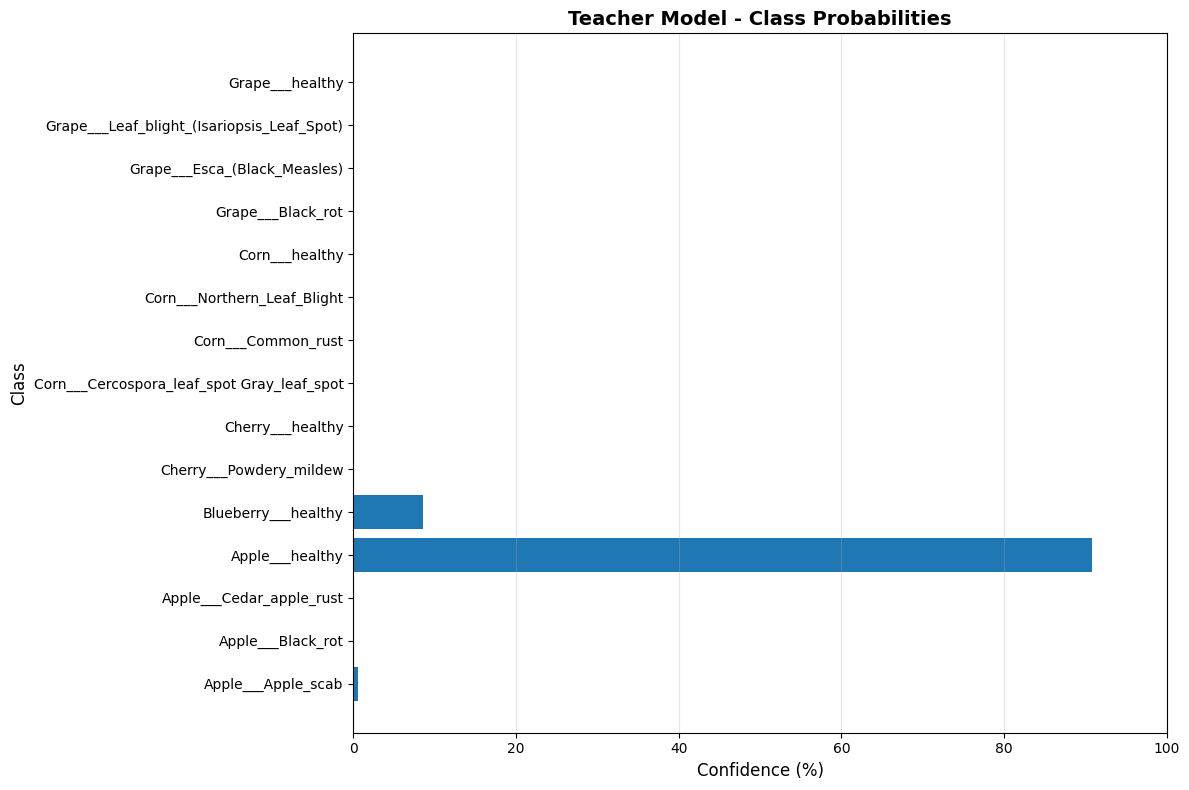

In [ ]:
from ultralytics import YOLO
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# 2. Load teacher for inference
student_model = YOLO('/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs/train5_student15c_resumed2/weights/best.pt')
# Predict
results = student_model("479.png")
result = results[0]
# print(results[1])
# Get all probabilities for all 15 classes
all_probs = result.probs.data.cpu().numpy()  # Shape: [15]

# Get class names
class_names = list(result.names.values())

# Print all class probabilities
print("\nAll Class Probabilities:")
print("-" * 50)
for idx, (name, prob) in enumerate(zip(class_names, all_probs)):
    print(f"{idx:2d}. {name:40s}: {prob * 100:6.2f}%")

# Visualize probability distribution
plt.figure(figsize=(12, 8))
plt.barh(class_names, all_probs * 100)
plt.xlabel('Confidence (%)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('Teacher Model - Class Probabilities', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


image 1/1 /content/479.png: 224x224 Apple___healthy 1.00, Apple___Apple_scab 0.00, Blueberry___healthy 0.00, Apple___Black_rot 0.00, Cherry___Powdery_mildew 0.00, 14.6ms
Speed: 3.9ms preprocess, 14.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

All Class Probabilities:
--------------------------------------------------
 0. Apple___Apple_scab                      :   0.07%
 1. Apple___Black_rot                       :   0.01%
 2. Apple___Cedar_apple_rust                :   0.00%
 3. Apple___healthy                         :  99.87%
 4. Blueberry___healthy                     :   0.04%
 5. Cherry___Powdery_mildew                 :   0.01%
 6. Cherry___healthy                        :   0.00%
 7. Corn___Cercospora_leaf_spot Gray_leaf_spot:   0.00%
 8. Corn___Common_rust                      :   0.00%
 9. Corn___Northern_Leaf_Blight             :   0.00%
10. Corn___healthy                          :   0.00%
11. Grape___Black_rot                       :   0.00%
12. G

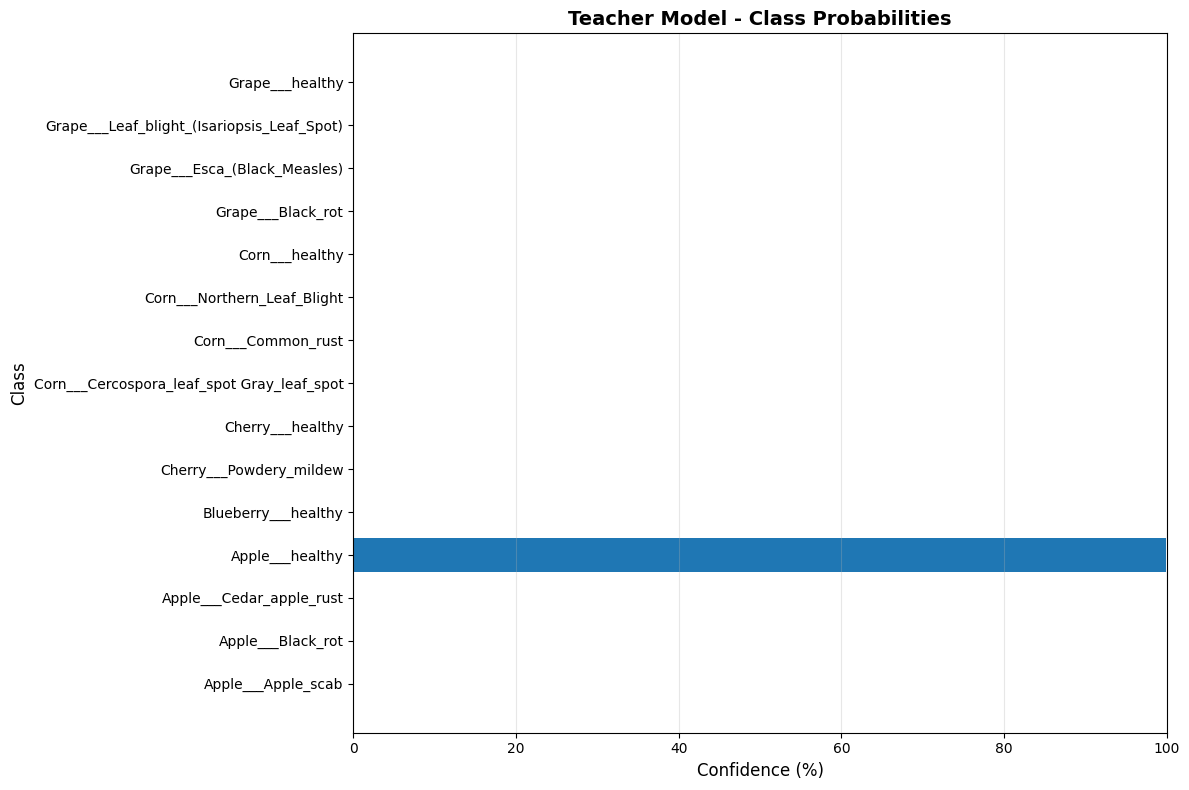

In [ ]:
from ultralytics import YOLO
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 2. Load teacher for inference
teacher_model = YOLO('/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs/train9_teacher15c/weights/best.pt')
# Predict
results = teacher_model("479.png")
result = results[0]

# Get all probabilities for all 15 classes
all_probs = result.probs.data.cpu().numpy()  # Shape: [15]

# Get class names
class_names = list(result.names.values())

# Print all class probabilities
print("\nAll Class Probabilities:")
print("-" * 50)
for idx, (name, prob) in enumerate(zip(class_names, all_probs)):
    print(f"{idx:2d}. {name:40s}: {prob * 100:6.2f}%")

# Visualize probability distribution
plt.figure(figsize=(12, 8))
plt.barh(class_names, all_probs * 100)
plt.xlabel('Confidence (%)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('Teacher Model - Class Probabilities', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

# Load last checkpoint (stopped at epoch 100)
model = YOLO('/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset/runs/train5_student15c/weights/last.pt')

# Train for 50 MORE epochs
model.train(
    data='/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset',
    epochs=7,      # If stopped at 100, this trains to 150
    imgsz=224,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset/runs',
    name='train5_student15c_resumed'  # New run name to avoid overwriting
)


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset/runs/train5_student15c/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=t

In [ ]:
!ls "/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs/train9_teacher15c/"

ls: cannot access '/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/runs/train9_teacher15c/': No such file or directory


In [ ]:
!ls "/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/test/Apple___Apple_scab"

In [ ]:
!cp "/content/drive/MyDrive/BE Major Project/Plant Village/fourclassdataset/" "/content/data"  -r

In [ ]:
from ultralytics import YOLO

# Load your trained model
# model = YOLO('/content/data/runs/student_distilled15c_new2/weights/best.pt')
model = YOLO('bestmod5.pt')

# Perform validation on the test set to get accuracy metrics
metrics = model.val(data="/content/data", split="test")
print(metrics)

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8-cls-student summary (fused): 21 layers, 432,975 parameters, 0 gradients, 2.4 GFLOPs
train: /content/data/train... found 10140 images in 15 classes ✅ 
val: /content/data/val... found 1445 images in 15 classes ✅ 
test: /content/data/test... found 2908 images in 15 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2653.8±882.7 MB/s, size: 112.5 KB)
test: Scanning /content/data/test... 2908 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2908/2908 3.7Kit/s 0.8s
test: New cache created: /content/data/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 182/182 13.9it/s 13.1s
                   all      0.771      0.983
Speed: 0.1ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/data/runs/train9_teacher15c/weights/best.pt')

# Perform validation on the test set to get accuracy metrics
metrics = model.val(data="/content/data", split="test")
print(metrics)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8-cls-teacher summary (fused): 54 layers, 56,142,415 parameters, 0 gradients, 153.8 GFLOPs
train: /content/data/train... found 10140 images in 15 classes ✅ 
val: /content/data/val... found 1445 images in 15 classes ✅ 
test: /content/data/test... found 2908 images in 15 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1969.1±777.2 MB/s, size: 112.5 KB)
test: Scanning /content/data/test... 2908 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2908/2908 5.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 182/182 10.3it/s 17.6s
                   all      0.974          1
Speed: 0.1ms preprocess, 4.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ef44f11760>
curves: []
curves_results: []

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/data/runs/studentraw/weights/best.pt')

# Perform validation on the test set to get accuracy metrics
metrics = model.val(data="/content/data", split="test")
print(metrics)

In [ ]:
from ultralytics import YOLO
import torch
import torch.nn as nn
import matplotlib as plt

# 2. Load teacher for inference
teacher_model = YOLO('/content/drive/MyDrive/BE Major Project (1)/Plant Village/fourclassdataset/student_distilled15c/train/weights/best.pt')
# Predict
results = teacher_model("479.png")
result = results[0]

# Get all probabilities for all 15 classes
all_probs = result.probs.data.cpu().numpy()  # Shape: [15]

# Get class names
class_names = list(result.names.values())

# Print all class probabilities
print("\nAll Class Probabilities:")
print("-" * 50)
for idx, (name, prob) in enumerate(zip(class_names, all_probs)):
    print(f"{idx:2d}. {name:40s}: {prob * 100:6.2f}%")

# Visualize probability distribution
plt.figure(figsize=(12, 8))
plt.barh(class_names, all_probs * 100)
plt.xlabel('Confidence (%)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('Teacher Model - Class Probabilities', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


🚀 CUSTOM KNOWLEDGE DISTILLATION

Device: cuda

📁 Loading data...
✓ Train samples: 10140
✓ Val samples: 1445
✓ Classes: 15

🎓 Loading teacher model...
✓ Teacher loaded and frozen

👨‍🎓 Creating student model...
✓ Student parameters: 1,276,511

⚙️ Training config:
   Alpha: 0.0
   Temperature: 4.0
   Epochs: 10
   Batch size: 16
   Learning rate: 0.001

🏋️ STARTING TRAINING



Epoch 1/10: 100%|██████████| 634/634 [01:19<00:00,  7.94it/s, Loss=0.7385, Hard=0.7385, Soft=7.1216]



Epoch 1/10
Train Loss: 1.1427 (Hard: 1.1427, Soft: 5.9594)
Val Loss: 0.6167 | Val Acc: 78.62%

✓ Best model saved! Accuracy: 78.62%



Epoch 2/10: 100%|██████████| 634/634 [01:17<00:00,  8.15it/s, Loss=0.4443, Hard=0.4443, Soft=8.8111]



Epoch 2/10
Train Loss: 0.5148 (Hard: 0.5148, Soft: 7.3126)
Val Loss: 0.5709 | Val Acc: 78.69%

✓ Best model saved! Accuracy: 78.69%



...


Epoch 8/10
Train Loss: 0.1687 (Hard: 0.1687, Soft: 12.8285)
Val Loss: 0.0895 | Val Acc: 97.09%

✓ Best model saved! Accuracy: 97.09%



Epoch 9/10: 100%|██████████| 634/634 [01:29<00:00,  7.12it/s, Loss=0.0968, Hard=0.0968, Soft=13.1148]



Epoch 9/10
Train Loss: 0.1515 (Hard: 0.1515, Soft: 13.5464)
Val Loss: 0.0818 | Val Acc: 96.96%



Epoch 10/10: 100%|██████████| 634/634 [01:17<00:00,  8.16it/s, Loss=0.0197, Hard=0.0197, Soft=17.0775]



Epoch 10/10
Train Loss: 0.1317 (Hard: 0.1317, Soft: 14.0599)
Val Loss: 0.0868 | Val Acc: 96.89%


✅ TRAINING COMPLETED!
Best Validation Accuracy: 97.09%
Model saved to: /content/data/newrun//best_student.pth

✓ Training curves saved to: /content/data/newrun//training_curves.png


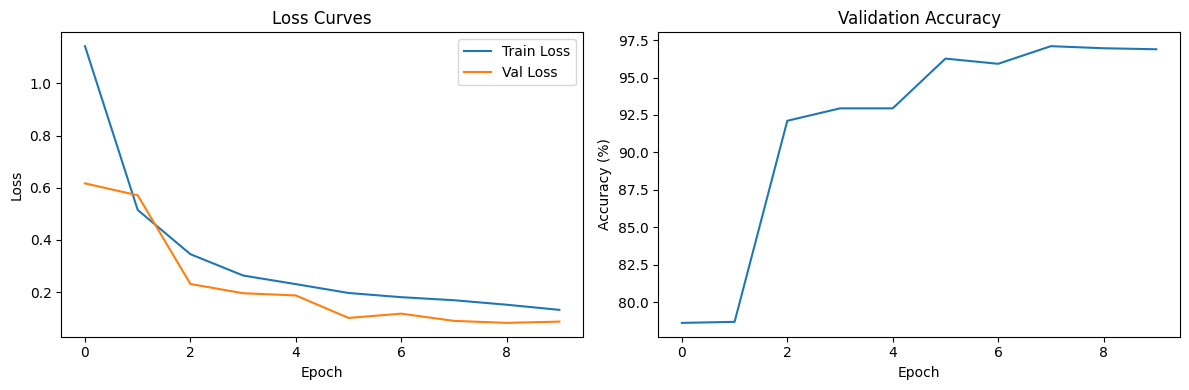

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==================== CONFIGURATION ====================
ALPHA = 0.0
TEMPERATURE = 4.0
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 0.001
NUM_CLASSES = 15
IMG_SIZE = 224
DATA_PATH = "/content/data"
TEACHER_PATH = "/content/data/runs/train9_teacher15c/weights/best.pt"
SAVE_DIR = "/content/data/newrun/"

os.makedirs(SAVE_DIR, exist_ok=True)

class Conv(nn.Module):
    """Standard convolution with BatchNorm and activation"""
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)  # SiLU (Swish) like YOLOv8

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class Bottleneck(nn.Module):
    """Standard bottleneck block with residual connection"""
    def __init__(self, in_channels, out_channels, shortcut=True, expansion=0.5):
        super().__init__()
        hidden_channels = int(out_channels * expansion)
        self.cv1 = Conv(in_channels, hidden_channels, 3, 1, 1)
        self.cv2 = Conv(hidden_channels, out_channels, 3, 1, 1)
        self.add = shortcut and in_channels == out_channels

    def forward(self, x):
        return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))

class C2f(nn.Module):
    """
    C2f module from YOLOv8 (faster implementation of CSP Bottleneck with 2 convolutions)

    Features:
    - Split input into two paths
    - Apply bottlenecks on one path
    - Concatenate all intermediate features
    - Final convolution to reduce channels
    """
    def __init__(self, in_channels, out_channels, n=1, shortcut=False, expansion=0.5):
        super().__init__()
        self.c = int(out_channels * expansion)  # hidden channels
        self.cv1 = Conv(in_channels, 2 * self.c, 1, 1)
        self.cv2 = Conv((2 + n) * self.c, out_channels, 1, 1)
        self.m = nn.ModuleList(Bottleneck(self.c, self.c, shortcut, expansion=1.0) for _ in range(n))

    def forward(self, x):
        y = list(self.cv1(x).chunk(2, 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, 1))

class SPPF(nn.Module):
    """Spatial Pyramid Pooling - Fast (SPPF) layer for YOLOv8"""
    def __init__(self, in_channels, out_channels, k=5):
        super().__init__()
        hidden_channels = in_channels // 2
        self.cv1 = Conv(in_channels, hidden_channels, 1, 1)
        self.cv2 = Conv(hidden_channels * 4, out_channels, 1, 1)
        self.m = nn.MaxPool2d(kernel_size=k, stride=1, padding=k // 2)

    def forward(self, x):
        x = self.cv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        return self.cv2(torch.cat((x, y1, y2, self.m(y2)), 1))

# ==================== CUSTOM STUDENT ARCHITECTURE ====================
class CustomStudentModel(nn.Module):
    """
    Lightweight custom student architecture

    Architecture:
    - 4 Conv blocks with BatchNorm + ReLU
    - Global Average Pooling
    - 2 FC layers with dropout

    Total params: ~500K (much smaller than teacher)
    """
    """
    Compact YOLOv8-inspired student model

    Architecture inspired by YOLOv8-nano but lighter:
    - Conv blocks with downsampling
    - C2f blocks for feature extraction
    - SPPF for spatial pyramid pooling
    - Simple classifier head

    Total params: ~600K (vs YOLOv8n's 3M+)
    """
    def __init__(self, num_classes=15):
        super().__init__()

        # Stem: 224x224x3 -> 112x112x16
        self.stem = Conv(3, 16, 3, 2, 1)

        # Stage 1: 112x112x16 -> 56x56x32
        self.stage1_conv = Conv(16, 32, 3, 2, 1)
        self.stage1_c2f = C2f(32, 32, n=1, shortcut=True)

        # Stage 2: 56x56x32 -> 28x28x64
        self.stage2_conv = Conv(32, 64, 3, 2, 1)
        self.stage2_c2f = C2f(64, 64, n=2, shortcut=True)

        # Stage 3: 28x28x64 -> 14x14x128
        self.stage3_conv = Conv(64, 128, 3, 2, 1)
        self.stage3_c2f = C2f(128, 128, n=2, shortcut=True)

        # Stage 4: 14x14x128 -> 7x7x256
        self.stage4_conv = Conv(128, 256, 3, 2, 1)
        self.stage4_c2f = C2f(256, 256, n=1, shortcut=True)

        # SPPF: Spatial pyramid pooling
        self.sppf = SPPF(256, 256, k=5)

        # Classification head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Backbone
        x = self.stem(x)

        x = self.stage1_conv(x)
        x = self.stage1_c2f(x)

        x = self.stage2_conv(x)
        x = self.stage2_c2f(x)

        x = self.stage3_conv(x)
        x = self.stage3_c2f(x)

        x = self.stage4_conv(x)
        x = self.stage4_c2f(x)

        x = self.sppf(x)

        # Head
        x = self.head(x)

        return x

    def fuse(self):
        """Fuse Conv and BN layers for inference speedup"""
        for m in self.modules():
            if isinstance(m, Conv):
                m.conv = nn.utils.fuse_conv_bn_eval(m.conv, m.bn)
                delattr(m, 'bn')
                m.forward = lambda x: m.act(m.conv(x))
        return self

# ==================== KNOWLEDGE DISTILLATION LOSS ====================
class DistillationLoss(nn.Module):
    """
    Knowledge Distillation Loss

    Combines:
    1. Hard loss (student vs ground truth): Cross-Entropy
    2. Soft loss (student vs teacher): KL Divergence on softened distributions
    """
    def __init__(self, alpha=0.5, temperature=4.0):
        super(DistillationLoss, self).__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, student_logits, teacher_logits, targets):
        # Hard loss: student learns from ground truth
        hard_loss = self.ce_loss(student_logits, targets)

        # Soft loss: student learns from teacher
        student_soft = F.log_softmax(student_logits / self.temperature, dim=1)
        teacher_soft = F.softmax(teacher_logits / self.temperature, dim=1)
        soft_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean') * (self.temperature ** 2)

        # Combined loss
        total_loss = self.alpha * soft_loss + (1 - self.alpha) * hard_loss

        return total_loss, hard_loss, soft_loss

# ==================== DATA LOADING ====================
def get_dataloaders(data_path, batch_size, img_size):
    """Create train and validation dataloaders"""

    # Data augmentation for training
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # No augmentation for validation
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load datasets
    train_dataset = datasets.ImageFolder(os.path.join(data_path, 'train'), transform=train_transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_path, 'val'), transform=val_transform)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"✓ Train samples: {len(train_dataset)}")
    print(f"✓ Val samples: {len(val_dataset)}")
    print(f"✓ Classes: {len(train_dataset.classes)}")

    return train_loader, val_loader, train_dataset.classes

# ==================== LOAD TEACHER MODEL ====================
def load_teacher(teacher_path, device):
    """Load pre-trained teacher model"""
    from ultralytics import YOLO

    teacher = YOLO(teacher_path)
    teacher.model = teacher.model.to(device).eval()

    # Freeze teacher
    for param in teacher.model.parameters():
        param.requires_grad = False

    print(f"✓ Teacher loaded and frozen")
    return teacher.model

# ==================== TRAINING FUNCTION ====================
def train_with_distillation(student, teacher, train_loader, val_loader, criterion, optimizer, device, epochs):
    """Train student model with knowledge distillation"""

    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ===== TRAINING =====
        student.train()
        train_loss = 0.0
        train_hard_loss = 0.0
        train_soft_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            student_logits = student(images)

            # Get teacher predictions
            with torch.no_grad():
                teacher_output = teacher(images)
                teacher_logits = teacher_output[1] if isinstance(teacher_output, (list, tuple)) else teacher_output

            # Compute distillation loss
            loss, hard_loss, soft_loss = criterion(student_logits, teacher_logits, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track losses
            train_loss += loss.item()
            train_hard_loss += hard_loss.item()
            train_soft_loss += soft_loss.item()

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Hard': f'{hard_loss.item():.4f}',
                'Soft': f'{soft_loss.item():.4f}'
            })

        avg_train_loss = train_loss / len(train_loader)
        avg_hard_loss = train_hard_loss / len(train_loader)
        avg_soft_loss = train_soft_loss / len(train_loader)

        # ===== VALIDATION =====
        student.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                student_logits = student(images)
                teacher_output = teacher(images)
                teacher_logits = teacher_output[1] if isinstance(teacher_output, (list, tuple)) else teacher_output

                loss, _, _ = criterion(student_logits, teacher_logits, labels)
                val_loss += loss.item()

                _, predicted = student_logits.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        # Save history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} (Hard: {avg_hard_loss:.4f}, Soft: {avg_soft_loss:.4f})")
        print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"{'='*60}\n")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': student.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': val_acc,
            }, os.path.join(SAVE_DIR, 'best_student.pth'))
            print(f"✓ Best model saved! Accuracy: {val_acc:.2f}%\n")

    return history, best_acc

# ==================== MAIN TRAINING SCRIPT ====================
def main():
    print(f"\n{'='*60}")
    print("🚀 CUSTOM KNOWLEDGE DISTILLATION")
    print(f"{'='*60}\n")

    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Load data
    print("\n📁 Loading data...")
    train_loader, val_loader, classes = get_dataloaders(DATA_PATH, BATCH_SIZE, IMG_SIZE)

    # Load teacher
    print("\n🎓 Loading teacher model...")
    teacher = load_teacher(TEACHER_PATH, device)

    # Create student
    print("\n👨‍🎓 Creating student model...")
    student = CustomStudentModel(num_classes=NUM_CLASSES).to(device)
    total_params = sum(p.numel() for p in student.parameters())
    print(f"✓ Student parameters: {total_params:,}")

    # Setup training
    criterion = DistillationLoss(alpha=ALPHA, temperature=TEMPERATURE)
    optimizer = torch.optim.Adam(student.parameters(), lr=LEARNING_RATE)

    print(f"\n⚙️ Training config:")
    print(f"   Alpha: {ALPHA}")
    print(f"   Temperature: {TEMPERATURE}")
    print(f"   Epochs: {EPOCHS}")
    print(f"   Batch size: {BATCH_SIZE}")
    print(f"   Learning rate: {LEARNING_RATE}")

    # Train
    print(f"\n{'='*60}")
    print("🏋️ STARTING TRAINING")
    print(f"{'='*60}\n")

    history, best_acc = train_with_distillation(
        student, teacher, train_loader, val_loader,
        criterion, optimizer, device, EPOCHS
    )

    print(f"\n{'='*60}")
    print(f"✅ TRAINING COMPLETED!")
    print(f"{'='*60}")
    print(f"Best Validation Accuracy: {best_acc:.2f}%")
    print(f"Model saved to: {SAVE_DIR}/best_student.pth")
    print(f"{'='*60}\n")

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'])
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Validation Accuracy')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'))
    print(f"✓ Training curves saved to: {SAVE_DIR}/training_curves.png")

if __name__ == "__main__":
    main()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv(nn.Module):
    """Standard convolution with BatchNorm and activation"""
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)  # SiLU (Swish) like YOLOv8

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class Bottleneck(nn.Module):
    """Standard bottleneck block with residual connection"""
    def __init__(self, in_channels, out_channels, shortcut=True, expansion=0.5):
        super().__init__()
        hidden_channels = int(out_channels * expansion)
        self.cv1 = Conv(in_channels, hidden_channels, 3, 1, 1)
        self.cv2 = Conv(hidden_channels, out_channels, 3, 1, 1)
        self.add = shortcut and in_channels == out_channels

    def forward(self, x):
        return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))

class C2f(nn.Module):
    """
    C2f module from YOLOv8 (faster implementation of CSP Bottleneck with 2 convolutions)

    Features:
    - Split input into two paths
    - Apply bottlenecks on one path
    - Concatenate all intermediate features
    - Final convolution to reduce channels
    """
    def __init__(self, in_channels, out_channels, n=1, shortcut=False, expansion=0.5):
        super().__init__()
        self.c = int(out_channels * expansion)  # hidden channels
        self.cv1 = Conv(in_channels, 2 * self.c, 1, 1)
        self.cv2 = Conv((2 + n) * self.c, out_channels, 1, 1)
        self.m = nn.ModuleList(Bottleneck(self.c, self.c, shortcut, expansion=1.0) for _ in range(n))

    def forward(self, x):
        y = list(self.cv1(x).chunk(2, 1))
        y.extend(m(y[-1]) for m in self.m)
        return self.cv2(torch.cat(y, 1))

class SPPF(nn.Module):
    """Spatial Pyramid Pooling - Fast (SPPF) layer for YOLOv8"""
    def __init__(self, in_channels, out_channels, k=5):
        super().__init__()
        hidden_channels = in_channels // 2
        self.cv1 = Conv(in_channels, hidden_channels, 1, 1)
        self.cv2 = Conv(hidden_channels * 4, out_channels, 1, 1)
        self.m = nn.MaxPool2d(kernel_size=k, stride=1, padding=k // 2)

    def forward(self, x):
        x = self.cv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        return self.cv2(torch.cat((x, y1, y2, self.m(y2)), 1))

class YOLOv8CompactStudent(nn.Module):
    """
    Compact YOLOv8-inspired student model

    Architecture inspired by YOLOv8-nano but lighter:
    - Conv blocks with downsampling
    - C2f blocks for feature extraction
    - SPPF for spatial pyramid pooling
    - Simple classifier head

    Total params: ~600K (vs YOLOv8n's 3M+)
    """
    def __init__(self, num_classes=15):
        super().__init__()

        # Stem: 224x224x3 -> 112x112x16
        self.stem = Conv(3, 16, 3, 2, 1)

        # Stage 1: 112x112x16 -> 56x56x32
        self.stage1_conv = Conv(16, 32, 3, 2, 1)
        self.stage1_c2f = C2f(32, 32, n=1, shortcut=True)

        # Stage 2: 56x56x32 -> 28x28x64
        self.stage2_conv = Conv(32, 64, 3, 2, 1)
        self.stage2_c2f = C2f(64, 64, n=2, shortcut=True)

        # Stage 3: 28x28x64 -> 14x14x128
        self.stage3_conv = Conv(64, 128, 3, 2, 1)
        self.stage3_c2f = C2f(128, 128, n=2, shortcut=True)

        # Stage 4: 14x14x128 -> 7x7x256
        self.stage4_conv = Conv(128, 256, 3, 2, 1)
        self.stage4_c2f = C2f(256, 256, n=1, shortcut=True)

        # SPPF: Spatial pyramid pooling
        self.sppf = SPPF(256, 256, k=5)

        # Classification head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Backbone
        x = self.stem(x)

        x = self.stage1_conv(x)
        x = self.stage1_c2f(x)

        x = self.stage2_conv(x)
        x = self.stage2_c2f(x)

        x = self.stage3_conv(x)
        x = self.stage3_c2f(x)

        x = self.stage4_conv(x)
        x = self.stage4_c2f(x)

        x = self.sppf(x)

        # Head
        x = self.head(x)

        return x

    def fuse(self):
        """Fuse Conv and BN layers for inference speedup"""
        for m in self.modules():
            if isinstance(m, Conv):
                m.conv = nn.utils.fuse_conv_bn_eval(m.conv, m.bn)
                delattr(m, 'bn')
                m.forward = lambda x: m.act(m.conv(x))
        return self

# Test the model
if __name__ == "__main__":
    model = YOLOv8CompactStudent(num_classes=15)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"{'='*60}")
    print(f"YOLOv8 Compact Student Model")
    print(f"{'='*60}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Test forward pass
    x = torch.randn(1, 3, 224, 224)
    y = model(x)
    print(f"Input shape: {x.shape}")
    print(f"Output shape: {y.shape}")
    print(f"{'='*60}")


YOLOv8 Compact Student Model
Total parameters: 1,276,511
Trainable parameters: 1,276,511
Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 15])
